# A/B Test Analysis: Homepage/Checkout Experiment
### Control vs Variant_A vs Variant_B

**Business question:** Our product/marketing team ran an experiment across three
visit-level variants. Should we roll out a variant, and if so, which one?

**This notebook covers:**
1. Pulling data live from PostgreSQL
2. Statistical significance testing (two-proportion z-test + chi-square)
3. Funnel visualization by group
4. Segment-level consistency checks (device, traffic source, country, loyalty tier)
5. Revenue & guardrail metrics (AOV, refund rate)
6. Revenue impact projection
7. Sample size / power retrospective
8. Executive summary & recommendation

**Data note:** `experiment_group` is assigned at the **visit/event level**, not the
customer level (99.96% of customers appear under more than one group across their
events). All metrics below are therefore computed at the visit level, which is the
correct unit of randomization for this dataset.


## 0. Setup

In [1]:

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Connect to PostgreSQL

Fill in your actual credentials below. Consider using environment variables
instead of hardcoding credentials if you plan to share this notebook publicly
(e.g. on GitHub) -- see the commented-out alternative.


In [2]:
# --- Option A: hardcode (fine for local/private use) ---
DB_USER = "postgres"
DB_PASSWORD = "lowrey123"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "postgres"


engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# quick connection test
pd.read_sql("SELECT 1 AS connection_ok;", engine)


,connection_ok
0,1


## 2. Primary metric: conversion rate by group

Pulls trial/success counts per group -- the direct input for the significance test.


In [3]:
query_primary = """
SELECT
    experiment_group,
    COUNT(*) AS n_visits,
    COUNT(*) FILTER (WHERE event_type = 'purchase') AS n_purchases
FROM events
GROUP BY experiment_group
ORDER BY experiment_group;
"""

primary = pd.read_sql(query_primary, engine)
primary["conversion_rate"] = primary["n_purchases"] / primary["n_visits"]
primary


,experiment_group,n_visits,n_purchases,conversion_rate
0,Control,627936,29839,0.0475
1,Variant_A,210588,10943,0.0520
2,Variant_B,210051,13127,0.0625


## 3. Statistical significance testing

Two-proportion z-test for each pairwise comparison, plus a 95% confidence
interval on the difference in conversion rate. This is the core of the analysis --
the number that tells you whether the observed lift is real or noise.


In [4]:
def two_proportion_ztest(x1, n1, x2, n2, alpha=0.05):
    """
    Two-proportion z-test.
    x1, n1: successes/trials for group 1 (variant)
    x2, n2: successes/trials for group 2 (baseline/control)
    Returns dict with rate diff, z-stat, p-value, and CI on the difference.
    """
    p1, p2 = x1 / n1, x2 / n2
    p_pool = (x1 + x2) / (n1 + n2)
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se_pool
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    # CI on the difference uses unpooled SE (standard approach for a CI)
    se_diff = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    z_crit = stats.norm.ppf(1 - alpha / 2)
    diff = p1 - p2
    ci_low, ci_high = diff - z_crit * se_diff, diff + z_crit * se_diff

    return {
        "group1_rate": p1, "group2_rate": p2, "diff": diff,
        "relative_lift_pct": 100 * diff / p2,
        "z_stat": z, "p_value": p_value,
        "ci_95_low": ci_low, "ci_95_high": ci_high,
        "significant_at_05": p_value < alpha,
    }

# pull counts into a lookup
counts = primary.set_index("experiment_group")[["n_visits", "n_purchases"]]

comparisons = [("Variant_A", "Control"), ("Variant_B", "Control"), ("Variant_B", "Variant_A")]
results = []
for grp, base in comparisons:
    x1, n1 = counts.loc[grp, "n_purchases"], counts.loc[grp, "n_visits"]
    x2, n2 = counts.loc[base, "n_purchases"], counts.loc[base, "n_visits"]
    r = two_proportion_ztest(x1, n1, x2, n2)
    r["comparison"] = f"{grp} vs {base}"
    results.append(r)

ztest_results = pd.DataFrame(results).set_index("comparison")
ztest_results[["group1_rate", "group2_rate", "diff", "relative_lift_pct",
               "z_stat", "p_value", "ci_95_low", "ci_95_high", "significant_at_05"]]


,group1_rate,group2_rate,diff,relative_lift_pct,z_stat,p_value,ci_95_low,ci_95_high,significant_at_05
comparison,,,,,,,,,
Variant_A vs Control,0.0520,0.0475,0.0044,9.3538,8.2059,0.0000,0.0034,0.0055,True
Variant_B vs Control,0.0625,0.0475,0.0150,31.5140,26.9376,0.0000,0.0138,0.0161,True
Variant_B vs Variant_A,0.0625,0.0520,0.0105,20.2646,14.7021,0.0000,0.0091,0.0119,True


In [5]:
# Overall chi-square test (all 3 groups at once) -- confirms there is
# *some* difference among groups before drilling into pairwise comparisons
contingency = np.array([
    [counts.loc[g, "n_purchases"], counts.loc[g, "n_visits"] - counts.loc[g, "n_purchases"]]
    for g in ["Control", "Variant_A", "Variant_B"]
])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.2f}, p-value: {p_chi2:.2e}, dof: {dof}")


Chi-square statistic: 725.43, p-value: 2.99e-158, dof: 2


## 4. Funnel visualization by group

Where does each group drop off? Home -> PLP -> PDP -> Cart -> Checkout -> Purchase.


In [6]:
query_funnel = """
SELECT
    experiment_group,
    COUNT(*) FILTER (WHERE page_category = 'Home')     AS "Home",
    COUNT(*) FILTER (WHERE page_category = 'PLP')       AS "PLP",
    COUNT(*) FILTER (WHERE page_category = 'PDP')       AS "PDP",
    COUNT(*) FILTER (WHERE page_category = 'Cart')      AS "Cart",
    COUNT(*) FILTER (WHERE page_category = 'Checkout')  AS "Checkout",
    COUNT(*) FILTER (WHERE event_type = 'purchase')     AS "Purchase"
FROM events
GROUP BY experiment_group
ORDER BY experiment_group;
"""

funnel = pd.read_sql(query_funnel, engine).set_index("experiment_group")
funnel


,Home,PLP,PDP,Cart,Checkout,Purchase
experiment_group,,,,,,
Control,125859,188785,188467,62098,62727,29839
Variant_A,41981,63249,63023,21192,21143,10943
Variant_B,41930,63096,63135,20869,21021,13127


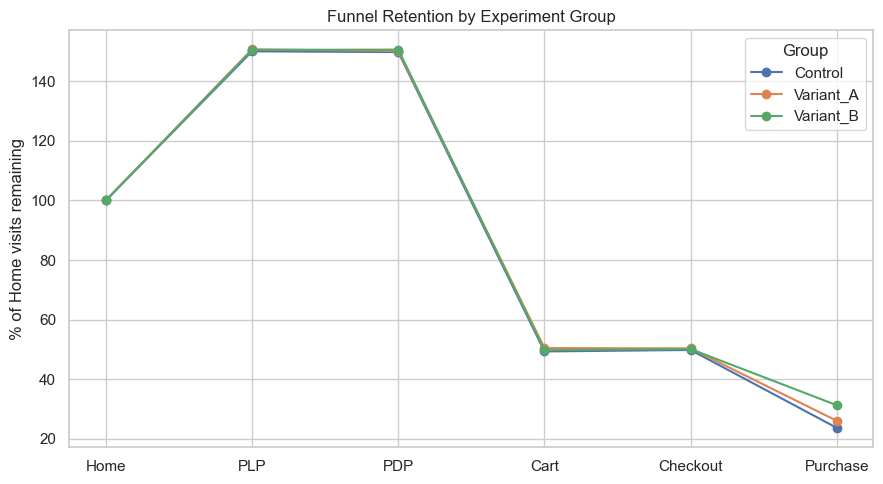

In [7]:
stages = ["Home", "PLP", "PDP", "Cart", "Checkout", "Purchase"]
funnel_pct = funnel[stages].div(funnel[stages]["Home"], axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
for grp in funnel_pct.index:
    ax.plot(stages, funnel_pct.loc[grp], marker="o", label=grp)

ax.set_ylabel("% of Home visits remaining")
ax.set_title("Funnel Retention by Experiment Group")
ax.legend(title="Group")
plt.tight_layout()
plt.show()


## 5. Segment-level consistency checks

Does the lift hold across device type, traffic source, country, and loyalty tier?
A variant that only "wins" in one segment (or reverses direction elsewhere) is a
much weaker recommendation than one that wins broadly -- this is the
Simpson's-paradox check.


In [14]:
def run_segment_ztests(df, segment_col):
    """
    df must have columns: [segment_col, 'experiment_group', 'n_visits', 'n_purchases']
    Runs Variant_B vs Control z-test within each segment value.
    """
    out = []
    for seg_val, sub in df.groupby(segment_col):
        sub = sub.set_index("experiment_group")
        if not {"Control", "Variant_B"}.issubset(sub.index):
            continue
        r = two_proportion_ztest(
            sub.loc["Variant_B", "n_purchases"], sub.loc["Variant_B", "n_visits"],
            sub.loc["Control", "n_purchases"], sub.loc["Control", "n_visits"],
        )
        r[segment_col] = seg_val
        out.append(r)
    return pd.DataFrame(out).set_index(segment_col)[
        ["group1_rate", "group2_rate", "diff", "relative_lift_pct", "p_value", "significant_at_05"]
    ]

segment_queries = {
    "device_type": """
        SELECT device_type, experiment_group, COUNT(*) AS n_visits,
               COUNT(*) FILTER (WHERE event_type = 'purchase') AS n_purchases
        FROM events GROUP BY device_type, experiment_group;
    """,
    "traffic_source": """
        SELECT INITCAP(traffic_source) AS traffic_source, experiment_group, COUNT(*) AS n_visits,
               COUNT(*) FILTER (WHERE event_type = 'purchase') AS n_purchases
        FROM events GROUP BY INITCAP(traffic_source), experiment_group;
    """,
    "country": """
        SELECT c.country, e.experiment_group, COUNT(*) AS n_visits,
               COUNT(*) FILTER (WHERE e.event_type = 'purchase') AS n_purchases
        FROM events e JOIN customers c ON c.customer_id = e.customer_id
        GROUP BY c.country, e.experiment_group;
    """,
    "loyalty_tier": """
        SELECT c.loyalty_tier, e.experiment_group, COUNT(*) AS n_visits,
               COUNT(*) FILTER (WHERE e.event_type = 'purchase') AS n_purchases
        FROM events e JOIN customers c ON c.customer_id = e.customer_id
        GROUP BY c.loyalty_tier, e.experiment_group;
    """,
}

segment_results = {}
for seg_name, q in segment_queries.items():
    seg_df = pd.read_sql(q, engine)
    segment_results[seg_name] = run_segment_ztests(seg_df, seg_name)
    print(f"--- {seg_name} (Variant_B vs Control) ---")
    display(segment_results[seg_name])


--- device_type (Variant_B vs Control) ---


,group1_rate,group2_rate,diff,relative_lift_pct,p_value,significant_at_05
device_type,,,,,,
desktop,0.0620,0.0476,0.0144,30.2873,0.0000,True
mobile,0.0630,0.0473,0.0158,33.3429,0.0000,True
tablet,0.0611,0.0497,0.0114,22.9056,0.0000,True


--- traffic_source (Variant_B vs Control) ---


,group1_rate,group2_rate,diff,relative_lift_pct,p_value,significant_at_05
traffic_source,,,,,,
Direct,0.0333,0.0162,0.0171,106.0464,0.0000,True
Email,0.0978,0.0842,0.0136,16.1202,0.0000,True
Organic,0.0328,0.0169,0.0159,93.8011,0.0000,True
Paid Search,0.0942,0.0806,0.0136,16.9395,0.0000,True
Social,0.0835,0.0690,0.0145,21.0535,0.0000,True


--- country (Variant_B vs Control) ---


,group1_rate,group2_rate,diff,relative_lift_pct,p_value,significant_at_05
country,,,,,,
AU,0.0634,0.0481,0.0153,31.7554,0.0000,True
BR,0.0612,0.0475,0.0137,28.9214,0.0000,True
CA,0.0661,0.0462,0.0199,43.0669,0.0000,True
DE,0.0614,0.0483,0.0131,27.0654,0.0000,True
IN,0.0619,0.0478,0.0141,29.5341,0.0000,True
UK,0.0633,0.0460,0.0174,37.7540,0.0000,True
US,0.0620,0.0479,0.0141,29.4366,0.0000,True


--- loyalty_tier (Variant_B vs Control) ---


,group1_rate,group2_rate,diff,relative_lift_pct,p_value,significant_at_05
loyalty_tier,,,,,,
Bronze,0.0572,0.0419,0.0153,36.6299,0.0000,True
Gold,0.0761,0.0630,0.0131,20.7792,0.0000,True
Platinum,0.0758,0.0623,0.0135,21.7383,0.0002,True
Silver,0.0673,0.0521,0.0153,29.3260,0.0000,True


## 6. Revenue & guardrail metrics

Conversion isn't the whole story -- check average order value and refund rate
too. A variant that drives more purchases but also more refunds is not a clean win.


In [9]:
query_revenue = """
WITH purchase_revenue AS (
    SELECT e.experiment_group, t.transaction_id, t.gross_revenue, t.refund_flag
    FROM events e
    JOIN transactions t ON t.customer_id = e.customer_id AND t.timestamp = e.timestamp
    WHERE e.event_type = 'purchase'
)
SELECT
    experiment_group,
    COUNT(*) AS n_orders,
    ROUND(SUM(gross_revenue)::numeric, 2) AS total_revenue,
    ROUND(AVG(gross_revenue)::numeric, 2) AS avg_order_value,
    COUNT(*) FILTER (WHERE refund_flag) AS n_refunds,
    ROUND(100.0 * COUNT(*) FILTER (WHERE refund_flag) / COUNT(*), 2) AS refund_rate_pct
FROM purchase_revenue
GROUP BY experiment_group
ORDER BY experiment_group;
"""

revenue = pd.read_sql(query_revenue, engine)
revenue


,experiment_group,n_orders,total_revenue,avg_order_value,n_refunds,refund_rate_pct
0,Control,29839,"2,440,672.7300",91.0200,880,2.9500
1,Variant_A,10943,"879,921.8100",89.5100,320,2.9200
2,Variant_B,13127,"1,041,043.2200",88.5400,373,2.8400


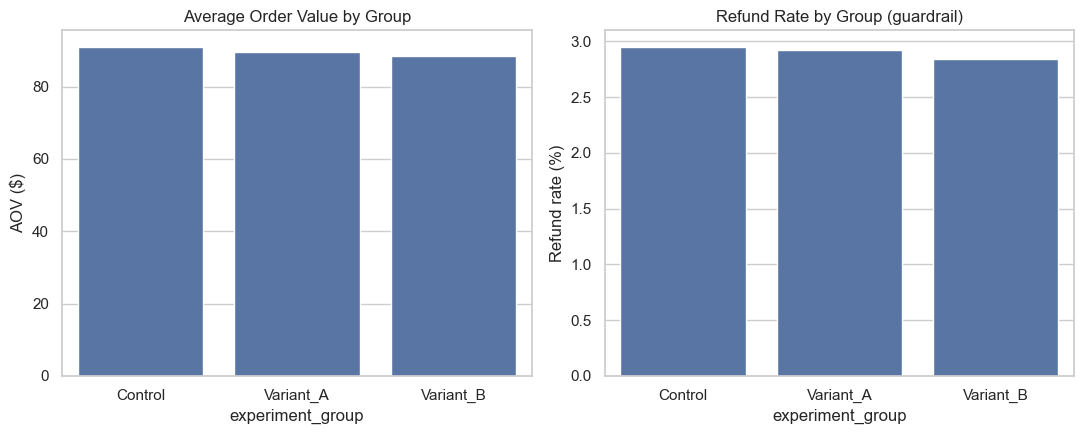

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(data=revenue, x="experiment_group", y="avg_order_value", ax=axes[0],
            order=["Control", "Variant_A", "Variant_B"])
axes[0].set_title("Average Order Value by Group")
axes[0].set_ylabel("AOV ($)")

sns.barplot(data=revenue, x="experiment_group", y="refund_rate_pct", ax=axes[1],
            order=["Control", "Variant_A", "Variant_B"])
axes[1].set_title("Refund Rate by Group (guardrail)")
axes[1].set_ylabel("Refund rate (%)")

plt.tight_layout()
plt.show()


In [11]:
# Bootstrap CI on Revenue Per Visit (RPV) -- more robust than a t-test here
# since per-visit revenue is zero-inflated (most visits don't purchase).

query_visit_revenue = """
SELECT
    e.experiment_group,
    COALESCE(t.gross_revenue, 0) AS revenue
FROM events e
LEFT JOIN transactions t
    ON t.customer_id = e.customer_id AND t.timestamp = e.timestamp AND e.event_type = 'purchase';
"""

visit_revenue = pd.read_sql(query_visit_revenue, engine)

def bootstrap_rpv_diff(df, group_a, group_b, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    a = df.loc[df.experiment_group == group_a, "revenue"].values
    b = df.loc[df.experiment_group == group_b, "revenue"].values
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        sa = rng.choice(a, size=len(a), replace=True)
        sb = rng.choice(b, size=len(b), replace=True)
        diffs[i] = sa.mean() - sb.mean()
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    return diffs.mean(), ci_low, ci_high

for grp in ["Variant_A", "Variant_B"]:
    mean_diff, lo, hi = bootstrap_rpv_diff(visit_revenue, grp, "Control")
    sig = "significant" if (lo > 0 or hi < 0) else "not significant"
    print(f"{grp} vs Control  RPV diff: {mean_diff:+.4f}  95% CI: [{lo:+.4f}, {hi:+.4f}]  -> {sig}")


Variant_A vs Control  RPV diff: +0.2925  95% CI: [+0.1518, +0.4310]  -> significant
Variant_B vs Control  RPV diff: +1.0686  95% CI: [+0.9204, +1.2194]  -> significant


## 7. Revenue impact projection

If we rolled the winning variant out to 100% of traffic (replacing Control),
what's the estimated revenue impact -- scaled to Control's current visit volume?


In [12]:
query_impact = """
WITH purchase_revenue AS (
    SELECT e.experiment_group, t.gross_revenue
    FROM events e
    JOIN transactions t ON t.customer_id = e.customer_id AND t.timestamp = e.timestamp
    WHERE e.event_type = 'purchase'
),
group_stats AS (
    SELECT v.experiment_group, v.n_visits,
           COALESCE(SUM(pr.gross_revenue), 0) / v.n_visits AS revenue_per_visit
    FROM (SELECT experiment_group, COUNT(*) AS n_visits FROM events GROUP BY experiment_group) v
    LEFT JOIN purchase_revenue pr ON pr.experiment_group = v.experiment_group
    GROUP BY v.experiment_group, v.n_visits
),
control AS (
    SELECT n_visits AS control_visits, revenue_per_visit AS control_rpv
    FROM group_stats WHERE experiment_group = 'Control'
)
SELECT
    gs.experiment_group,
    ROUND(gs.revenue_per_visit::numeric, 4) AS revenue_per_visit,
    ROUND((gs.revenue_per_visit - c.control_rpv)::numeric, 4) AS uplift_per_visit_vs_control,
    ROUND((c.control_visits * (gs.revenue_per_visit - c.control_rpv))::numeric, 2)
        AS projected_incremental_revenue
FROM group_stats gs CROSS JOIN control c
WHERE gs.experiment_group <> 'Control'
ORDER BY gs.experiment_group;
"""

impact = pd.read_sql(query_impact, engine)
impact


,experiment_group,revenue_per_visit,uplift_per_visit_vs_control,projected_incremental_revenue
0,Variant_A,4.1784,0.2916,"183,097.7700"
1,Variant_B,4.9561,1.0693,"671,469.1600"
